# Introduction to today's case study on dataframes

**Objective:** Learn how to use basic statistics with Pandas dataframes in Python to analyze green jobs data.

Green jobs are becoming increasingly important in today's economy. In this lesson, you will learn how to use basic statistics with Pandas dataframes in Python to analyze green jobs data.

So what are some examples of "green jobs"

* Engineers who design systems and technologies to address environmental issues such as air and water pollution, waste management, and sustainable development.
* Scientists who study ecosystems, wildlife habitats, and natural resources to develop conservation plans aimed at protecting biodiversity and preserving ecosystems.
* Professionals who manage recycling programs, educate communities on proper recycling practices, and develop initiatives to reduce waste and promote recycling efforts.
* Workers who install solar panels on residential or commercial properties to generate clean, renewable energy from sunlight.




## Loading and Manipulating Data

To get started, we will load a CSV file containing green jobs data using Pandas:


In [ ]:
# add code here


#Descriptive Statistics

<p>Descriptive statistics is a branch of statistics that deals with summarizing and describing the main features of a dataset. It involves the calculation and analysis of measures that provide insight into the distribution, central tendency, and variability of the data.</p>

<h2>Measures of Central Tendency (and Some Data Cleaning!)</h2>
<p>Measures of central tendency provide information about the center or typical value of a dataset. The three most common measures of central tendency are:</p>

<ul>
	<li>Mean: the arithmetic average of the data</li>
	<li>Median: the middle value in the sorted data</li>
	<li>Mode: the most frequently occurring value in the data</li>
</ul>




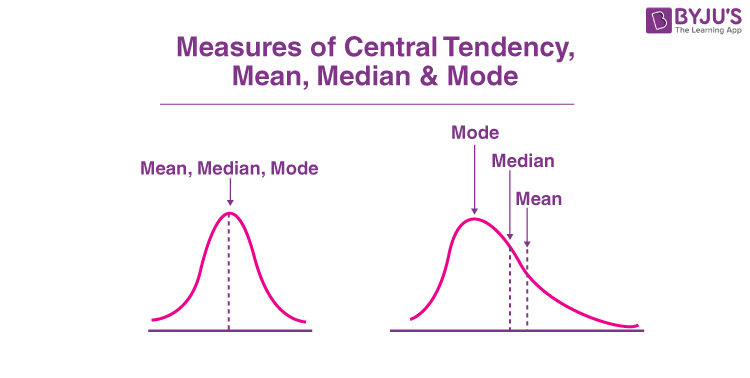

Look back at our notes from last class about how to calculate the mean for the Number of Jobs column in the green_jobs.csv dataset:

In [ ]:
# add code here
# Calculate the mean number of jobs


Let's check the data types of our columns using `.dtypes`. This will tell us if the columns are numbers, text, or other data types.

In [ ]:
green_jobs_df.dtypes

But that's weird, I thought they were numbers...?

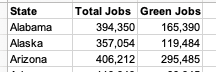

Ah those commas are causing the issue!

To convert a string containing a comma to a float in Python, you need to first remove the comma and then convert it to a float. Here's how you can do it:

In [ ]:
# Sample string containing a comma
string_with_comma = "1,234.56"

# Remove comma and convert to float
float_value = float(string_with_comma.replace(',', ''))

print(float_value)  # Output: 1234.56

In [ ]:
# List of columns containing commas to be converted to numeric
columns_with_commas = ['Total Jobs', 'Green Jobs']

# Remove commas and convert to numeric
for column in columns_with_commas:
    green_jobs_df[column] = green_jobs_df[column].str.replace(',', '').astype(float)

# Check the data types after conversion
print(green_jobs_df.dtypes)

This code snippet iterates through the specified columns (`'Total Jobs'` and `'Green Jobs'`) and performs two main operations:

1.  **`green_jobs_df[column].str.replace(',', '')`**: This part of the code accesses the specified column and uses the `.str.replace()` method to remove all occurrences of the comma (`,`) character from the strings in that column.
2.  **`.astype(float)`**: After removing the commas, this part of the code converts the resulting string values in the column to floating-point numbers.

By doing this for each column in the `columns_with_commas` list, the code effectively cleans the data, making it suitable for numerical calculations like finding the mean, median, and mode.

Another efficient way to handle commas in numeric columns when loading data is to use the `thousands` argument in the `pd.read_csv()` function. Check out the documentation for read_csv if you are curious!

Now let's try calculating the mean again...

In [ ]:
# Calculate the mean number of jobs
mean_jobs = green_jobs_df['Total Jobs'].mean()
print('Mean jobs:', mean_jobs)

https://pandas.pydata.org/docs/reference/frame.html

Look at the documentation, how would you do this for median and mode?

In [ ]:
# add code here


## Common bugs during calculations

Calculating the mean, median, and mode is a common task in data analysis. While these measures are straightforward to calculate, there are some common bugs people can run into that can affect the accuracy of the calculations.

One common bug is **incorrect data types**. For example, if you have a dataset where the values are stored as strings instead of numbers, attempting to calculate the mean will result in a TypeError. We saw one of these already!


Another common bug is **missing or invalid data**. If you have missing or invalid data in your dataset, attempting to calculate the mean or median will result in NaN (Not a Number) values. We will talk more about that in a future lesson!

**Unevenly spaced data** can also affect the accuracy of the mean calculation. For example, if you have a dataset where the data is collected at irregular intervals over time, the mean may not be a good measure of the average value. In this case, you may want to use other measures of central tendency such as the median or mode instead.



## Measures of Variability
<p>Measures of variability provide information about the spread or dispersion of the data. The three most common measures of variability are:</p>

<ul>
	<li>Range: the difference between the maximum and minimum values in the data</li>
	<li>Variance: the average of the squared differences from the mean</li>
	<li>Standard deviation: the square root of the variance</li>
</ul>

For more info: https://numiqo.com/tutorial/dispersion-parameter



Each of the three measures of variability - range, variance, and standard deviation - has its own strengths and limitations, and the choice of which measure to use depends on the specific characteristics of the dataset and the research question.

**Range**: The range is a simple measure of variability that provides a quick and easy way to estimate the spread of the data. It is useful when you want a quick estimate of how much the data varies, but it is sensitive to outliers and can be influenced by extreme values in the dataset.

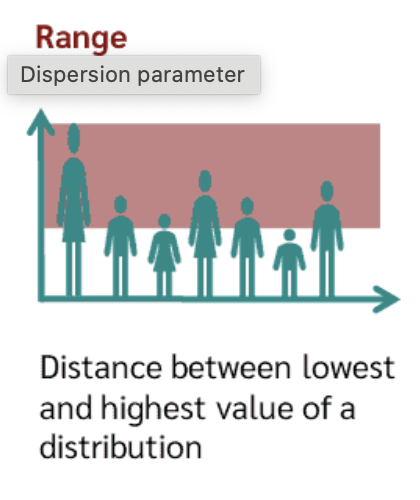

While there isn't a single built-in .range() function for pandas Series or DataFrames like there is for .mean(), you can easily calculate the range by subtracting the minimum value from the maximum value.

In [ ]:
# Calculate the range of the 'Total Jobs' column
jobs_range = green_jobs_df['Total Jobs'].max() - green_jobs_df['Total Jobs'].min()
print('Range of jobs:', jobs_range)


**Variance**: The variance is a more precise measure of variability that takes into account the differences of each data point from the mean. It is useful when you want a more accurate estimate of the variability of the data, but it can be sensitive to outliers and the interpretation of the variance is not as intuitive as the range or standard deviation.

Variance is calculated by squaring the difference between each data point and the mean, summing these squared differences, and then dividing by the number of data points (or n-1 for sample variance). When you square the differences, large differences (which are common with outliers) become even larger, disproportionately affecting the variance.

Now what about the syntax for variance? Look at the documentation!

https://pandas.pydata.org/docs/reference/frame.html

In [ ]:
# Calculate the variance of the 'Total Jobs' column
jobs_variance = green_jobs_df['Total Jobs'].var()
print('Variance of jobs:', jobs_variance)




**Standard deviation:** The standard deviation is a popular and widely used measure of variability that is similar to the variance, but is easier to interpret.

Standard Deviation is simply the square root of the variance. Taking the square root does bring the value back to the *original scale* of the data, making it easier to interpret than variance. However, since it's derived directly from the variance, it still carries the amplified impact of those squared differences caused by outliers.

It is useful when you want a measure of variability that is both accurate and easy to understand.


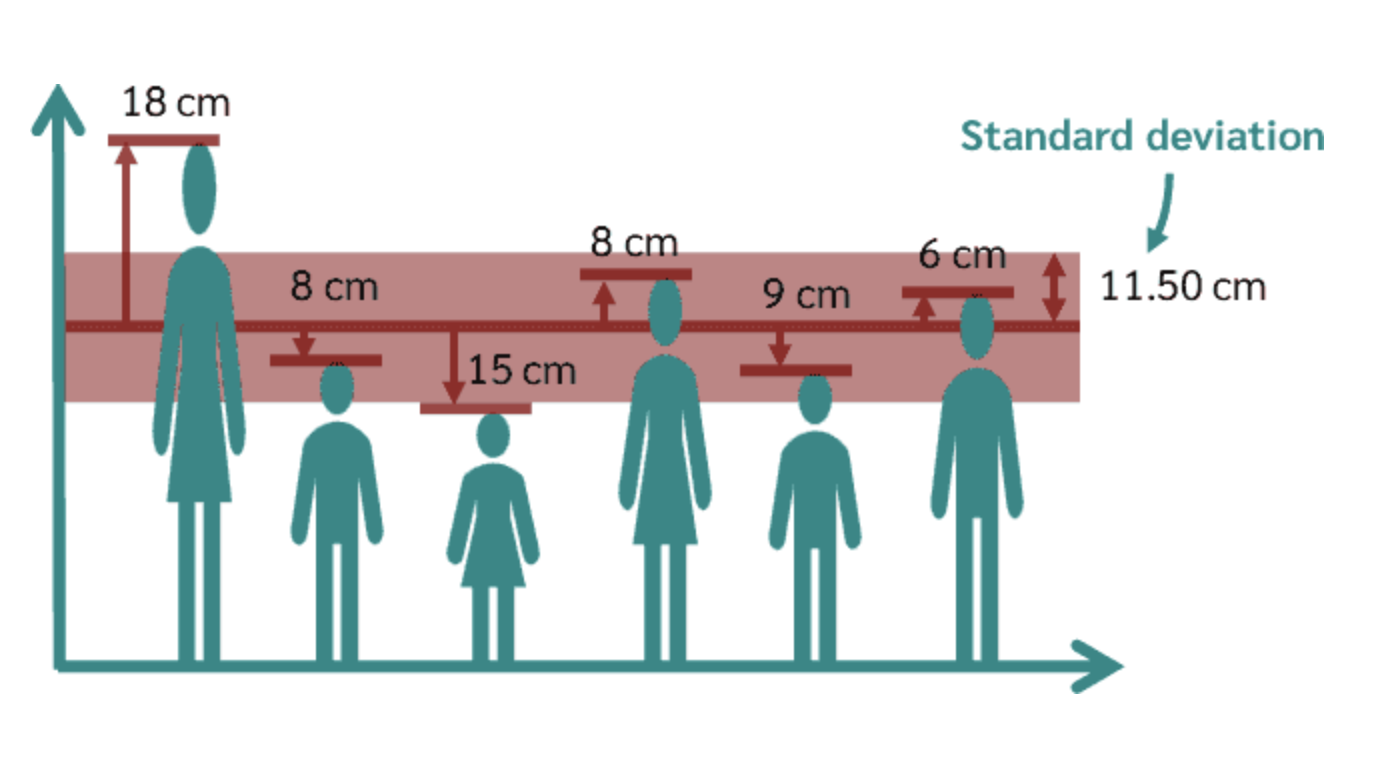

In [ ]:
# Calculate the standard deviation of the 'Total Jobs' column
jobs_std_dev = green_jobs_df['Total Jobs'].std()
print('Standard deviation of jobs:', jobs_std_dev)

In general, the choice of which measure of variability to use depends on the specific characteristics of the dataset and the research question. If you are interested in getting a quick estimate of the spread of the data, the range may be sufficient. If you want a more accurate and precise estimate of the variability of the data, the variance or standard deviation may be more appropriate. If your dataset has outliers or extreme values, you may want to use a measure of variability that is less sensitive to outliers, such as the **interquartile range **or trimmed mean deviation.


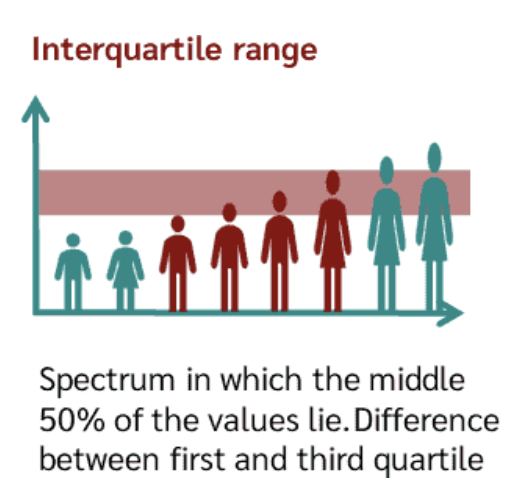

## visualizing variability
Another way to visualize the variability of your data is to make a histogram.

Histograms are particularly useful for visualizing the distribution of continuous data, helping to identify patterns, central tendency, variability, and outliers within the dataset. (we talked about this in a previous lesson!!)

Key features of a histogram include:

* Bins: The range of values is divided into intervals called bins or buckets. Each bin represents a specific range of values.
* Frequency: The height of each bar represents the frequency of observations within the corresponding bin.
* X-axis: Typically represents the range of values or categories being measured.
* Y-axis: Represents the frequency or count of observations falling within each bin.

In [ ]:
import matplotlib.pyplot as plt

fig_hist, ax_hist = plt.subplots()
ax_hist.hist(green_jobs_df['Total Jobs'], bins=10)
ax_hist.set_xlabel('Total Jobs')
ax_hist.set_ylabel('Frequency')
ax_hist.set_title('Histogram of Total Jobs')
fig_hist

FYI if you want to rotate your axes so its more readable, here is the syntax:

In [ ]:
fig_hist2, ax_hist2 = plt.subplots()
ax_hist2.hist(green_jobs_df['Total Jobs'], bins=5)
ax_hist2.set_xlabel('Total Jobs')
ax_hist2.set_ylabel('Frequency')
ax_hist2.set_title('Histogram of Total Jobs')
ax_hist2.tick_params(axis='x', rotation=45)
fig_hist2

There are also built in functions to pandas if you want to plot every numeric column in your dataframe.

In [ ]:
green_jobs_df.hist()

Now you try! Find the mean, median, mode, range, standard deviation, and variance for the green jobs column and then make a histogram where the bars are green.

In [ ]:
# you add your code
# Calculate the mean number of 'Green Jobs'


# Calculate the median number of 'Green Jobs'


# Calculate the mode of the number of 'Green Jobs'


# Calculate the range of the 'Green Jobs' column


# Calculate the variance of the 'Green Jobs' column


# Calculate the standard deviation of the 'Green Jobs' column


You might have noticed that the output for the mode is presented as a Series (which looks similar to a list or array). This is because a dataset can have more than one mode if multiple values appear with the same highest frequency. Pandas' `.mode()` function returns a Series to accommodate the possibility of multiple modes. If there's only one mode, the Series will just contain that single value!

In [ ]:
# you add your code

# Plot histogram


Is there a good way to visualize both sets of information though so we can start to compare them? Yup! There is!

You can create a bar chart that shows the mean of each column and then has error bars that represent either the range, variance, or the standard deviation depending on your application.

Deciding what to represent with error bars (range, variance, or standard deviation) depends on what aspect of the data's variability you want to emphasize or visualize.

**Range**: If you're interested in showing the full extent of the data and want to highlight the minimum and maximum values, using the range can be helpful. This provides a clear indication of the spread of values within each column.

**Variance**: Variance measures the average squared deviation from the mean. It gives you an idea of how much individual values differ from the mean value. Using variance as error bars can be suitable when you want to show the overall dispersion of the data points around the mean.

**Standard Deviation:** Standard deviation is a measure of the amount of variation or dispersion of a set of values. It provides a more interpretable measure of dispersion compared to variance because it's in the same units as the original data. Using standard deviation as error bars is common and provides a clear representation of the typical deviation from the mean.


In most cases, **standard deviatio**n is preferred because it's a widely used and easily interpretable measure of variability. However, depending on the specific characteristics of your data and the message you want to convey, you may choose to use range or variance as well.

So let's try to make that bar chart now.

In [ ]:
import matplotlib.pyplot as plt
columns = ['Total Jobs', 'Green Jobs']
mean_values = [mean_jobs, g_mean_jobs]
std_vals = [jobs_std_dev, g_jobs_std_dev]

fig_bars, ax_bars = plt.subplots()
ax_bars.bar(columns, mean_values, yerr=std_vals)
ax_bars.set_xlabel('Metrics')
ax_bars.set_ylabel('Number of Jobs')
ax_bars.set_title('Green Jobs Statistics')
fig_bars

**Reminder:** Important to note here that so far we have created a historgram and a bar chart and while they may look similar at first, they are not representing the same thing

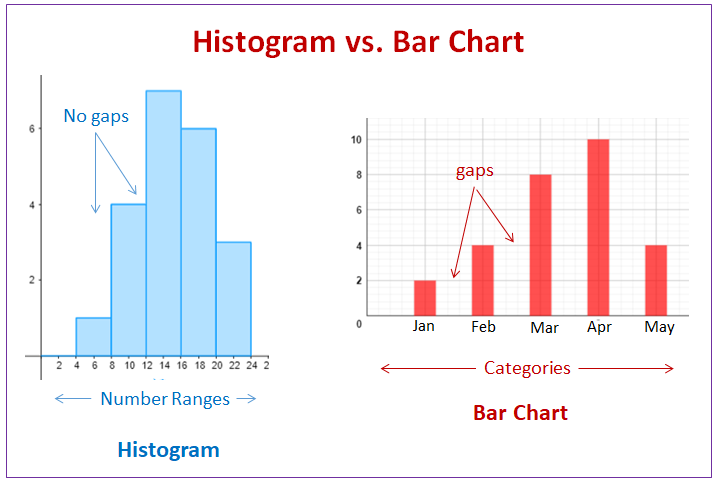

**Bar Chart**: A bar chart is used to compare different categories or groups of data. It displays categorical data with rectangular bars whose lengths are proportional to the values they represent. Bar charts are commonly used to show comparisons between discrete categories. In a bar chart, the x-axis typically represents categories or groups, while the y-axis represents the values being measured (e.g., counts, percentages, etc.).

**Histogram:** A histogram is used to represent the distribution of continuous data. It shows the frequency distribution of a single variable by dividing the data into intervals (bins) and displaying the number of observations that fall into each interval. Histograms are useful for visualizing the shape, center, and spread of a dataset. In a histogram, both axes represent the numerical values of the variable being measured. The x-axis represents the variable's range, divided into intervals (bins), while the y-axis represents the frequency or density of observations within each interval.


Additionally, we can another tool, the **box plot** (sometimes referred to as a the box and whiskers plot)

The box plot shows the minimum and maximum values of the data (the whiskers), the lower and upper quartiles (the boxes), and the median (the horizontal line inside the box). The plot provides a visual representation of the range of the data, and can also help identify outliers that may be present in the dataset.







In [ ]:
fig_box, ax_box = plt.subplots()
ax_box.boxplot(green_jobs_df['Total Jobs'])
ax_box.set_title('Boxplot of Total Jobs')
ax_box.set_xlabel('Total Jobs')
fig_box

Your turn, make a box plot with the total job information and the green job information.

In [ ]:
# your code here


But now we have this 1 2 instead of our column names. How can we put our column names there. You can use the method xticks.

In [ ]:
fig_box3, ax_box3 = plt.subplots()
ax_box3.boxplot([green_jobs_df['Total Jobs'], green_jobs_df['Green Jobs']])
ax_box3.set_xticks([1, 2])
ax_box3.set_xticklabels(['Total Jobs', 'Green Jobs'])
ax_box3.set_title('Boxplot')
ax_box3.set_ylabel('# jobs')
fig_box3

and again if you just want to plot every numeric column as a box plot you can call this

In [ ]:
green_jobs_df.boxplot()

and if you only have certain columns you want to plot you can make a subset dataframe and then use the .boxplot() method built into pandas on that.

**In class assignment!** Try:
* making a subset dataframe that only has the columns 'Total Jobs' and 'Green Jobs'
* using the built in pandas function for box plot, make a box plot of your subset dataframe
* look at the documentation to figure out how to turn off the grid

submit an image of your code and boxplot as the inclass assignment for today!

In [ ]:
# your code here




---
## 📋 Today's In-Class Assignment

**The exercise above is your in-class assignment for today. Submit it to Canvas before you leave.**

To submit:
1. Make sure your code in the cell above runs without errors (press Shift+Enter to run it)
2. Take a screenshot of your code and its output
3. Go to the module on Canvas that this lesson was part of and find today's in-class assignment, due at midnight
4. Upload your screenshot

*If you have multiple screenshots, combine them into a single PDF before uploading.*

**You only need to show that you tried; this is graded on effort, not perfection.**

---

## What I hope you learned

By working through this notebook, you should now be familiar with:

* Loading and cleaning data in Pandas DataFrames.
* Calculating measures of central tendency (mean, median, mode).
* Calculating measures of variability (range, variance, standard deviation).
* Visualizing data distributions using histograms and box plots.
* Creating bar charts with error bars to compare metrics.